In [48]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
import ot
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std

In [2]:
human_dir = 'data/tabula_sapiens/'
mouse_dir = 'data/tabula_muris/'

In [4]:
human_adatas = top_n_organisms_from_species(human_dir, 6, 'human')

In [3]:
mouse_adatas = top_n_organisms_from_species(mouse_dir, 20, 'mouse')

In [98]:
# Calculate random mean given n cells
pairs = [(0,1),(2,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15),(16,17),(18,19)]

In [63]:
random_mean, random_std = calc_random_mean_std(mouse_adatas, pairs, 100)

/tmp/ipykernel_1867789/1356134152.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if types1[cell_num] == types2[cell_num]:
/tmp/ipykernel_1867789/1356134152.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if types1[cell_num] == types2[cell_num]:
/tmp/ipykernel_1867789/1356134152.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if types1[cell_num] == types2[cell_num]:
/tmp/ipykernel_1867789/1356134152.py:12: FutureWarni

In [100]:
random_mean

np.float64(0.10880000000000001)

In [101]:
random_ste

np.float64(0.05079921259232273)

### Study influence of PCA (dim 5, 10, 25, 50, 100) on mouse-mouse results with 100 cells

In [25]:
num_cells = 50
pca_dim_list = [5, 10, 50, 100]
pairs = [(0,1),(2,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15),(16,17),(18,19)]
pca_dims_for_plot = []
pca_accs_for_plot = []

for pca_dim in pca_dim_list:
    for mouse_adata in mouse_adatas:
        sc.pp.pca(mouse_adata, n_comps = pca_dim)
    for pair in pairs:
        m1, m2 = sample_equal_cell_types(mouse_adatas[pair[0]], mouse_adatas[pair[1]], num_cells)
        acc, p = ot_between_organisms(m1, m2, num_cells, epsilon=0.01)
        pca_accs_for_plot.append(acc)
    pca_dims_for_plot += [pca_dim] * len(pairs)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-p

In [26]:
pca_data_plot = pd.DataFrame({'pca_dim':pca_dims_for_plot,
                              'accuracy':pca_accs_for_plot})

Text(0.5, 1.0, 'Cell type matching accuracy vs PCA dimensions, mouse-mouse, 50 cells')

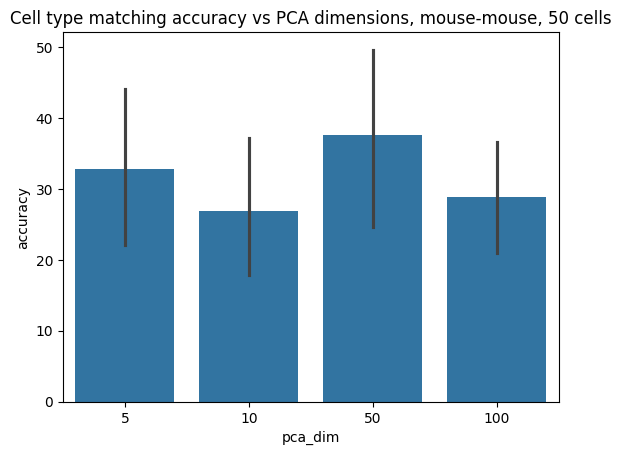

In [27]:
sns.barplot(pca_data_plot, x='pca_dim', y='accuracy')
plt.title('Cell type matching accuracy vs PCA dimensions, mouse-mouse, 50 cells')

In [73]:
random_mean*100

np.float64(10.894)

Text(0.5, 1.0, 'Cell type matching accuracy vs PCA dimensions, mouse-mouse, 100 cells')

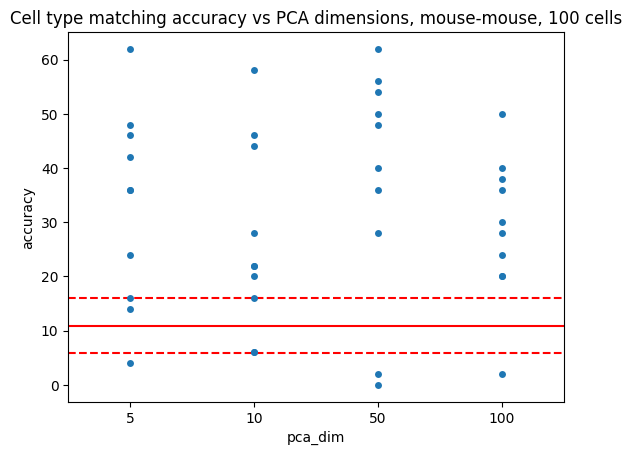

In [115]:
ax = sns.stripplot(pca_data_plot, x='pca_dim', y='accuracy', jitter=0)
ax.hlines(y=random_mean*100, xmin = -0.5, xmax=3.5, color='r')
ax.hlines(y=(random_mean-random_std)*100, xmin = -0.5, xmax=3.5, color='r', linestyles='--')
ax.hlines(y=(random_mean+random_std)*100, xmin = -0.5, xmax=3.5, color='r', linestyles='--')
ax.set_xlim(-0.5,3.5)
plt.title('Cell type matching accuracy vs PCA dimensions, mouse-mouse, 100 cells')

### Study influence of Sinkhorn epsilon (1e-7, 1e-6, 1e-6, 1e-4, 1-e3, 0.01, 0.1) on mouse-mouse results with 100 cells

In [4]:
# redo PCA in 50 dims
for mouse_adata in mouse_adatas:
    sc.pp.pca(mouse_adata, n_comps = 50)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, init

In [14]:
num_cells = 100
epsilon_list = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 0.01, 0.1]
pairs = [(0,1),(2,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15),(16,17),(18,19)]
epsilons_for_plot = []
epsilon_accs_for_plot = []

for epsilon in epsilon_list:
    for pair in pairs:
        m1, m2 = sample_equal_cell_types(mouse_adatas[pair[0]], mouse_adatas[pair[1]], num_cells)
        acc, p = ot_between_organisms(m1, m2, num_cells, epsilon)
        epsilon_accs_for_plot.append(acc)
    epsilons_for_plot += [epsilon] * len(pairs)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:643: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/gromov/_bregman.py:245: UserWarning: Solver failed to produce a transport plan. You might want to increase the regularization parameter `epsilon`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarni

In [15]:
epsilon_data_plot = pd.DataFrame({'epsilon':epsilons_for_plot,
                              'accuracy':epsilon_accs_for_plot})

Text(0.5, 1.0, 'Cell type matching accuracy vs Sinkhorn epsilon, mouse-mouse, 100 cells')

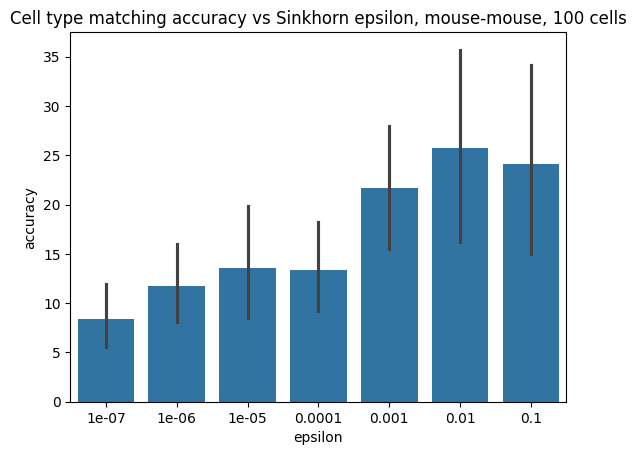

In [16]:
sns.barplot(epsilon_data_plot, x='epsilon', y='accuracy')
plt.title('Cell type matching accuracy vs Sinkhorn epsilon, mouse-mouse, 100 cells')

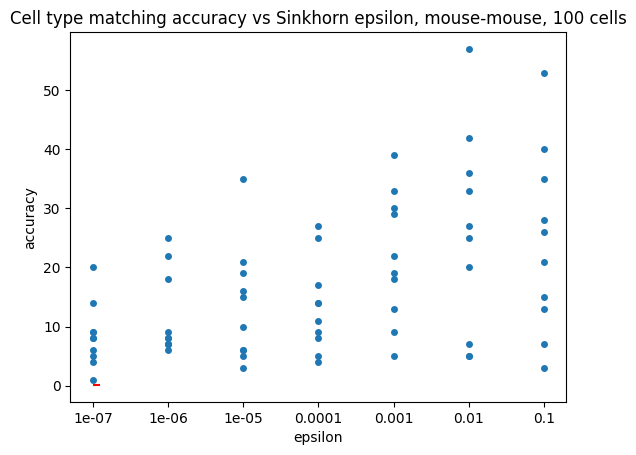

In [57]:
sns.stripplot(x='epsilon', y='accuracy', data=epsilon_data_plot, jitter=0, size=5)
plt.title('Cell type matching accuracy vs Sinkhorn epsilon, mouse-mouse, 100 cells')

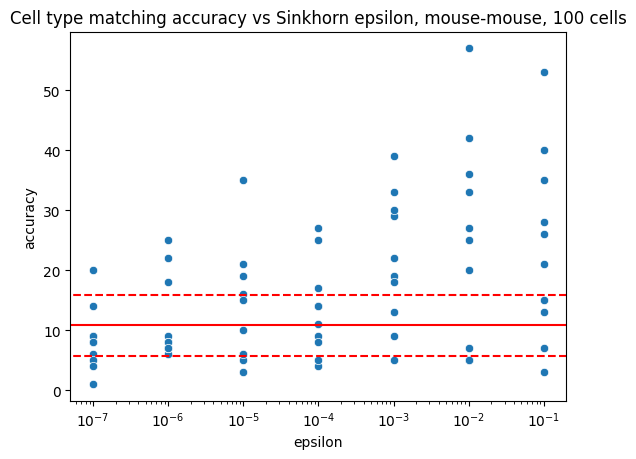

In [120]:
sns.scatterplot(epsilon_data_plot, x='epsilon', y='accuracy')
plt.xscale('log')
ax.hlines(y=random_mean*100, xmin = 1e-8, xmax=1, color='r')

ax.set_xlim(-0.5,3.5)
plt.title('Cell type matching accuracy vs Sinkhorn epsilon, mouse-mouse, 100 cells')
plt.hlines(y=random_mean_100*100, xmin = 1e-8, xmax=1, color='r')
plt.hlines(y=(random_mean-random_std)*100, xmin = 1e-8, xmax=1, color='r', linestyles='--')
plt.hlines(y=(random_mean+random_std)*100, xmin = 1e-8, xmax=1, color='r', linestyles='--')

### Visualize how increasing n changes alignment

In [169]:
n_list = [10, 50, 100, 200, 300]
pairs = [(0,1),(2,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15),(16,17),(18,19)]
epsilon = 0.01
n_accs_for_plot, n_for_plot = [], []

for n in n_list:
    for pair in pairs:
        m1, m2 = sample_equal_cell_types(mouse_adatas[pair[0]], mouse_adatas[pair[1]], n)
        acc, p = ot_between_organisms(m1, m2, n, epsilon)
        n_accs_for_plot.append(acc)
    n_for_plot += [n] * len(pairs)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-p

In [179]:
n_data_plot = pd.DataFrame({'cells_included':n_for_plot,
                              'accuracy':n_accs_for_plot})

Text(0.5, 1.0, 'Cell type matching accuracy vs # cells included, mouse-mouse')

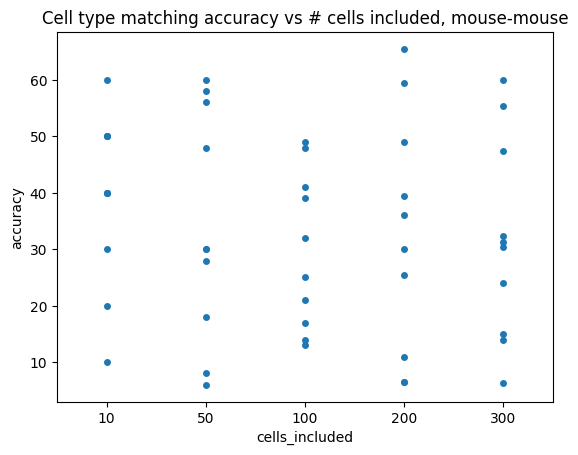

In [180]:
sns.stripplot(x='cells_included', y='accuracy', data=n_data_plot, jitter=0, size=5)
plt.title('Cell type matching accuracy vs # cells included, mouse-mouse')